# **舞蹈種類判別 + 特徵差異視覺化（2025ver.）**
- 舞蹈種類：台灣原住民祭儀舞、芭蕾、街舞、現代舞…
- 多風格舞蹈辨識系統（每個舞種有自己的 Encoder）

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from pathlib import Path
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

*****

### **STEP 1：定義 Encoder（共用架構）**

In [2]:
class MotionEncoder(nn.Module):
    def __init__(self, input_dim=177, hidden_dim=256, embed_dim=256, num_layers=3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim*2, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(embed_dim, embed_dim)
        )
    def forward(self, x):
        out, (h, c) = self.lstm(x)
        emb = torch.cat([h[-2], h[-1]], dim=-1)
        return self.proj(emb)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

*****

### **STEP 2：自動載入（每種舞蹈專屬的 Encoder）**
#### 資料夾結構：
- data/weights_by_style/
  1. twa/             → lstm_encoder_best.pth
  2. ballet/          → lstm_encoder_best.pth
  3. .../             → lstm_encoder_best.pth
  4. .../             → lstm_encoder_best.pth

=================================================
- data/segments_by_style/
  1. twa/             ← 臺灣原住民舞蹈
  2. ballet/          ← 芭蕾
  3. .../             ← ...
  4. .../             ← ...


In [3]:
WEIGHTS_ROOT = Path("data/weights_by_style")
DATA_ROOT    = Path("data/segments_by_style")

# 自動掃描所有舞蹈類別
categories = [p.name for p in DATA_ROOT.iterdir() if p.is_dir() and (WEIGHTS_ROOT / p.name).exists()]
print(f"發現 {len(categories)} 種支援專屬 encoder 的舞蹈：{categories}")

# 載入每種舞蹈的專屬 encoder
encoders = {}
for cat in categories:
    weight_path = WEIGHTS_ROOT / cat / "lstm_encoder_best.pth"
    if not weight_path.exists():
        raise FileNotFoundError(f"找不到 {weight_path}！請確認每種舞都有自己的 weights 資料夾")
    
    encoder = MotionEncoder().to(device)
    encoder.load_state_dict(torch.load(weight_path, map_location=device))
    encoder.eval()
    encoders[cat] = encoder
    print(f"The dedicated semantic encoder {cat:12} has been loaded")

發現 2 種支援專屬 encoder 的舞蹈：['ballet', 'twa']
The dedicated semantic encoder ballet       has been loaded
The dedicated semantic encoder twa          has been loaded


*****

### **STEP 3：開始提取語意特徵 Embedding（每種舞用自己的 Encoder）**
- 處理 ballet       → x 段                                                                                                                  
- 處理 twa          → y 段                                                                                                                  
- 總共提取 x+y 個語意向量 → shape: (x+y, 256)

In [4]:
embeddings = []
labels = []
label_to_idx = {name: idx for idx, name in enumerate(categories)}

print("\nStart extracting semantic features (each dance uses its own encoder)...")
with torch.no_grad():
    for cat in categories:
        cat_path = DATA_ROOT / cat
        files = list(cat_path.glob("*.pt"))
        encoder = encoders[cat]  # 關鍵！用這類的專屬 encoder
        
        print(f"  Process {cat:12} → {len(files)} segments")
        for pt_file in tqdm(files, leave=False):
            seq = torch.load(pt_file)  # (60,177) or smaller
            if seq.shape[0] < 60:
                pad = torch.zeros(60 - seq.shape[0], 177)
                seq = torch.cat([seq, pad], dim=0)
            seq = seq.to(device)
            
            emb = encoder(seq.unsqueeze(0)).cpu().numpy()[0]  # (256,)
            embeddings.append(emb)
            labels.append(label_to_idx[cat])

embeddings = np.array(embeddings)
labels = np.array(labels)
print(f"A total of {len(embeddings)} semantic vectors were extracted → shape: {embeddings.shape}")


Start extracting semantic features (each dance uses its own encoder)...
  Process ballet       → 672 segments


  Process twa          → 5605 segments


A total of 6277 semantic vectors were extracted → shape: (6277, 256)


*****

### **STEP 4：t-SNE 視覺化（sklearn）**

Running t-SNE (this may take 10-30 seconds)...
sklearn version: 1.7.1


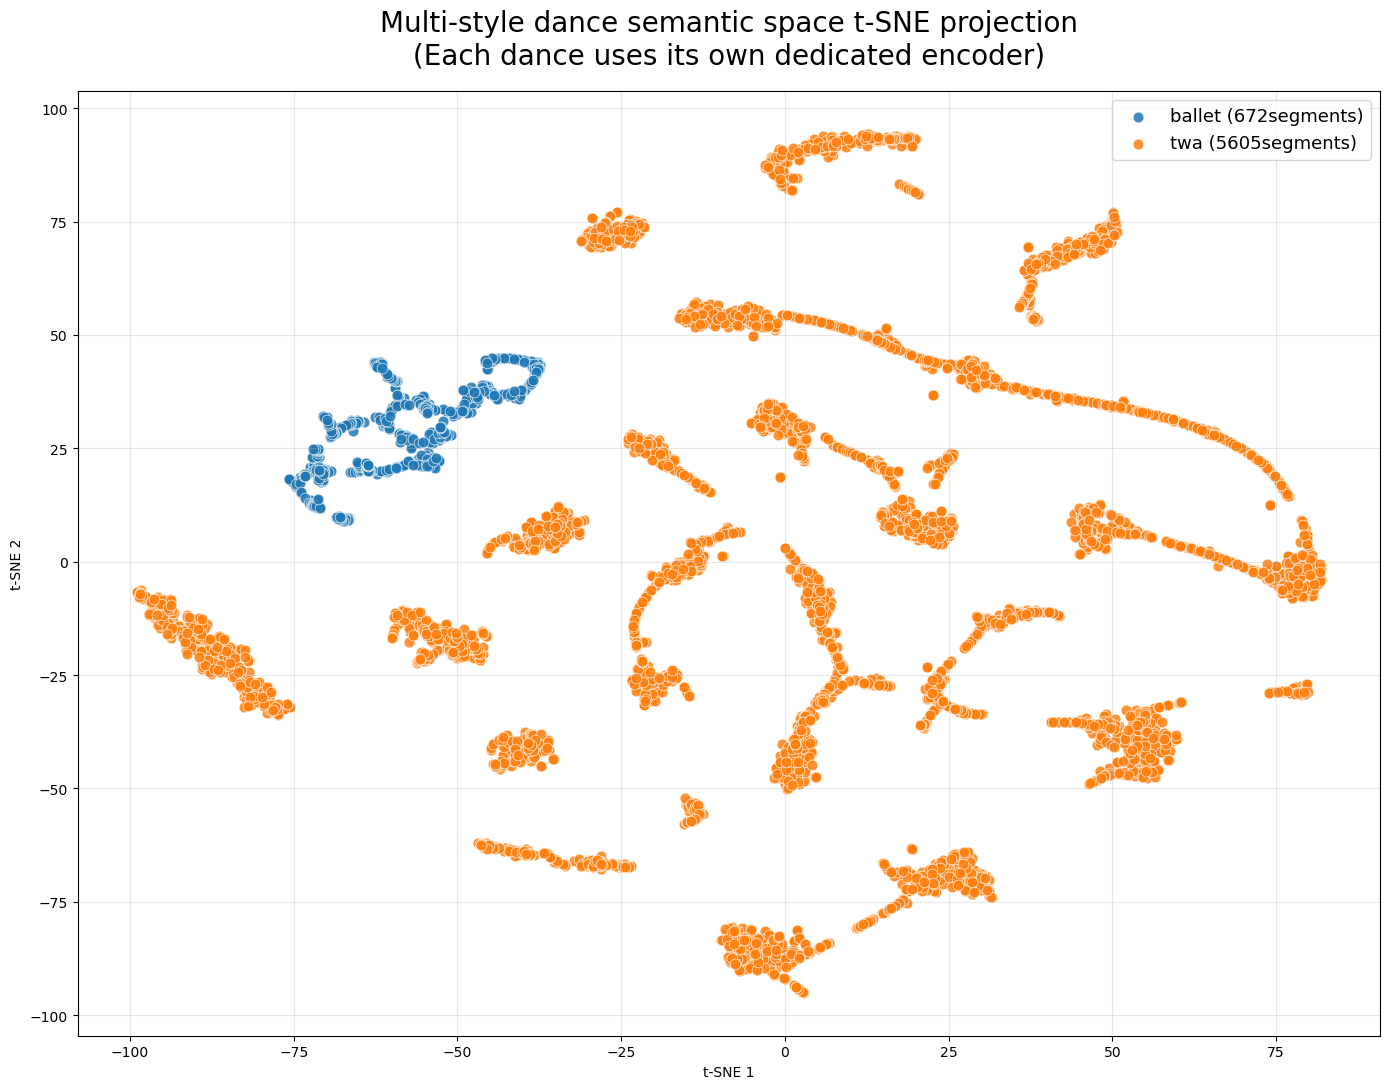

In [5]:
print("Running t-SNE (this may take 10-30 seconds)...")

# 自動偵測 sklearn 版本
from sklearn.manifold import TSNE
import sklearn
sklearn_version = sklearn.__version__
print(f"sklearn version: {sklearn_version}")

tsne_kwargs = {
    "n_components": 2,
    "perplexity": min(40, len(embeddings)//5),  # 自動避免 perplexity 太大
    "random_state": 42,
    "init": "pca",           # 新版推薦，避免警告
    "learning_rate": "auto", # 新版推薦
}

# 舊版用 n_iter，新版用 max_iter
if int(sklearn_version.split('.')[0]) >= 1 and int(sklearn_version.split('.')[1]) >= 2:
    tsne_kwargs["max_iter"] = 2000
else:
    tsne_kwargs["n_iter"] = 2000

tsne = TSNE(**tsne_kwargs)
tsne_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(14, 11))
palette = sns.color_palette("tab10", len(categories))
for i, cat in enumerate(categories):
    mask = labels == i
    plt.scatter(tsne_2d[mask, 0], tsne_2d[mask, 1], 
                label=f"{cat} ({mask.sum()}segments)", s=60, alpha=0.85, edgecolors='white', linewidth=0.5)
plt.legend(fontsize=13, loc='best')
plt.title("Multi-style dance semantic space t-SNE projection\n (Each dance uses its own dedicated encoder) ", fontsize=20, pad=20)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*****

### **STEP 5：訓練一個跨風格分類器（KNN）**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels)

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train, y_train)
acc = knn.score(X_test, y_test)
print(f"\nCross-style classification accuracy: {acc*100:.2f}%")

print("\nDetailed report: ")
print(classification_report(y_test, knn.predict(X_test), target_names=categories))


Cross-style classification accuracy: 100.00%

Detailed report: 
              precision    recall  f1-score   support

      ballet       1.00      1.00      1.00       134
         twa       1.00      1.00      1.00      1122

    accuracy                           1.00      1256
   macro avg       1.00      1.00      1.00      1256
weighted avg       1.00      1.00      1.00      1256



*****

### **STEP 6：預測函數（自動選 Encoder）**
- 輸入：(60,177) tensor 或 .pt 檔案路徑
- 輸出：自動選擇最適合的 Encoder 進行判別 + 信心分數

In [7]:
def predict_dance_style_auto(segment_tensor_or_path):
    # 讀取資料
    if isinstance(segment_tensor_or_path, (str, Path)):
        seq = torch.load(segment_tensor_or_path)
    else:
        seq = segment_tensor_or_path
        
    if seq.shape[0] < 60:
        pad = torch.zeros(60 - seq.shape[0], 177)
        seq = torch.cat([seq, pad], dim=0)
    
    seq = seq.to(device)
    
    # 對每種 Encoder 都試一次，取信心最高者
    best_cat = None
    best_conf = -1
    best_probs = None
    
    with torch.no_grad():
        for cat, encoder in encoders.items():
            emb = encoder(seq.unsqueeze(0)).cpu().numpy()
            prob = knn.predict_proba(emb)[0]
            conf = prob.max()
            if conf > best_conf:
                best_conf = conf
                best_cat = cat
                best_probs = {c: float(p) for c, p in zip(categories, prob)}
    
    return {
        "prediction": best_cat,
        "confidence": float(best_conf),
        "used_encoder": best_cat,  # 可以知道用了哪個專屬 Encoder
        "all_probabilities": best_probs
    }

*****

### **STEP 7：即時測試**

In [8]:
print("\nInstant test (randomly selected segment)")
test_files = list(DATA_ROOT.glob("*/*.pt"))
test_file = np.random.choice(test_files)
result = predict_dance_style_auto(test_file)

print(f"Test Files: {test_file}")
print(json.dumps(result, indent=2, ensure_ascii=False))


Instant test (randomly selected segment)
Test Files: data\segments_by_style\twa\seg_03579.pt
{
  "prediction": "ballet",
  "confidence": 1.0,
  "used_encoder": "ballet",
  "all_probabilities": {
    "ballet": 1.0,
    "twa": 0.0
  }
}
